# CISC7204 Assignment 01 — Module 05 / Lab 01: Car model evaluation and refinement

**Submitted by:** Xiji Hang (MC646933).

**Laboratory collaborators:** Xiji Hang (MC646933) and Xiaoyu Guo (MC648131).  
**Collaboration:** All laboratory work is undertaken jointly by both students.

**Data:** [module_5_auto.csv](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/module_5_auto.csv). Each row is an automobile record with price in USD. Horsepower is measured in hp; the target and prescribed predictors are complete.
The supplied educational snapshot is loaded independently from `../datasets/raw/module_5_auto.csv`;
it is not assumed to be identical to an earlier laboratory's exported data. Raw data are preserved.

**Evaluation scope:** Prescribed split and CV demonstrations are retained. Repeated degree/alpha comparisons use a development-validation subset, not an untouched final test.

**Local adaptation:** This working copy runs in local Anaconda/Jupyter. Browser-only
installation/download cells are replaced with local imports and data paths. Supplied solution
dropdowns and stale example answers are omitted; the original template remains unchanged.
Numbered questions and their order are retained. IBM template authorship and attribution appear below.

**AI acknowledgement:** [OpenAI Codex](https://openai.com/codex/) was used for coding,
debugging and wording assistance. Numerical results were produced by executing this notebook.

<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Model Evaluation and Refinement


Estimated time needed: **30** minutes
    

## Objectives

After completing this lab you will be able to:

* Evaluate and refine prediction models
* Identify overfitting and underfittin of models
* Perform Ridge regression for polynomial feature models
* Use Grid search to identify best choice of hyperparameters


<h2>Table of Contents</h2>
<ul>
    <li><a href="#ref1">Model Evaluation </a></li>
    <li><a href="#ref2">Over-fitting, Under-fitting and Model Selection </a></li>
    <li><a href="#ref3">Ridge Regression </a></li>
    <li><a href="#ref4">Grid Search</a></li>
</ul>


The supplied IBM snapshot is preserved locally; its original URL and SHA-256 digest are recorded below.

The local Anaconda environment provides the libraries. Unpinned package-install commands are not executed inside this analysis.

In [1]:
# Figures use 300 DPI for readable high-resolution exports.
from pathlib import Path
import hashlib
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display, Markdown
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import (train_test_split, cross_val_score,
                                    cross_val_predict, GridSearchCV)
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 300,
                     'axes.titlesize': 12, 'axes.labelsize': 11,
                     'legend.fontsize': 9, 'figure.constrained_layout.use': True})
pd.set_option('display.max_columns', 8)
pd.set_option('display.precision', 4)
print(f'Python {sys.version.split()[0]} | pandas {pd.__version__} | '
      f'NumPy {np.__version__} | scikit-learn {sklearn.__version__} | '
      f'seaborn {sns.__version__} | matplotlib {matplotlib.__version__}')

def density_plot(actual, predicted, title):
    fig, ax = plt.subplots()
    sns.kdeplot(x=actual, label='Observed', color='#1c768f', ax=ax)
    sns.kdeplot(x=predicted, label='Fitted', color='#df6b37', ax=ax)
    ax.set(title=title, xlabel='Price (USD)', ylabel='Density (1/USD)')
    ax.legend()
    plt.show()

def locate_dataset(filename):
    # Accept a flat submission, the bundle root, or the notebooks subfolder.
    folders = (Path.cwd(), Path.cwd() / 'datasets' / 'raw',
               Path.cwd().parent / 'datasets' / 'raw')
    for folder in folders:
        candidate = folder / filename
        if candidate.is_file():
            return candidate.resolve()
    searched = ', '.join(str(folder / filename) for folder in folders)
    raise FileNotFoundError(f'Missing required dataset {filename}. Searched: {searched}')

def output_root_for(data_file):
    folder = data_file.resolve().parent
    if folder.name == 'raw' and folder.parent.name == 'datasets':
        return folder.parent.parent
    return folder

def metrics_row(label, actual, predicted):
    assert np.isfinite(predicted).all(), 'Predictions must be finite.'
    return {'Model': label, 'R²': r2_score(actual, predicted),
            'MSE (USD²)': mean_squared_error(actual, predicted)}

Python 3.14.6 | pandas 3.0.3 | NumPy 2.4.6 | scikit-learn 1.9.0 | seaborn 0.13.2 | matplotlib 3.11.0


In [2]:
path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/module_5_auto.csv'
input_path = locate_dataset('module_5_auto.csv')
assert input_path.is_file()
df = pd.read_csv(input_path)
print('Source:',path)
print('SHA-256:',hashlib.sha256(input_path.read_bytes()).hexdigest())
display(df.head())

Source: https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/module_5_auto.csv
SHA-256: 0f95cfcf08621aa3b8fba21f26ed980a0c2e2adb843796666fef6971d6300a9c


,Unnamed: 0.1,Unnamed: 0,symboling,normalized-losses,...,city-L/100km,horsepower-binned,diesel,gas
0,0,0,3,122,...,11.1905,Medium,0,1
1,1,1,3,122,...,11.1905,Medium,0,1
2,2,2,1,122,...,12.3684,Medium,0,1
3,3,3,2,164,...,9.7917,Medium,0,1
4,4,4,2,164,...,13.0556,Medium,0,1


In [3]:
export_path = output_root_for(input_path) / 'build/m04_m05/exports/module_5_auto.csv'
export_path.parent.mkdir(parents=True,exist_ok=True)
df.to_csv(export_path,index=False)
print(f'Guided CSV copy saved: {export_path}; {len(df)} rows, raw input unchanged.')

Guided CSV copy saved: /Users/Admin/Documents/ChatGPT/CISC7204 Data Science and Data Visualization/Assignment01_Working/build/m04_m05/exports/module_5_auto.csv; 201 rows, raw input unchanged.


Select numeric data as instructed. Export-index columns are metadata rather than predictors; they are removed from the working DataFrame. Required models use an explicit feature list.

In [4]:
export_columns = [c for c in df.columns if c.startswith('Unnamed:')]
df = df.drop(columns=export_columns).select_dtypes(include=np.number)
print('Removed export-index columns:',export_columns)
required_features = ['horsepower', 'curb-weight', 'engine-size', 'highway-mpg', 'normalized-losses', 'symboling']
required_columns = required_features + ['price']
assert set(required_columns).issubset(df.columns)
assert df[required_columns].notna().all().all()
assert np.isfinite(df[required_columns].to_numpy(dtype=float)).all()
print(f'Rows: {len(df)}; columns: {df.shape[1]}; duplicate rows: {df.duplicated().sum()}')
print('Missing values:', {c: int(n) for c, n in df.isna().sum().items() if n})
print('Required model inputs and target: complete and finite; no rows removed.')
display(df.head())

Removed export-index columns: ['Unnamed: 0.1', 'Unnamed: 0']
Rows: 201; columns: 19; duplicate rows: 0
Missing values: {'stroke': 4}
Required model inputs and target: complete and finite; no rows removed.


,symboling,normalized-losses,wheel-base,length,...,price,city-L/100km,diesel,gas
0,3,122,88.6,0.8111,...,13495.0,11.1905,0,1
1,3,122,88.6,0.8111,...,16500.0,11.1905,0,1
2,1,122,94.5,0.8227,...,16500.0,12.3684,0,1
3,2,164,99.8,0.8486,...,13950.0,9.7917,0,1
4,2,164,99.4,0.8486,...,17450.0,13.0556,0,1


The numeric working snapshot retains four missing stroke values, which are not used by any required model. No model rows are dropped. The supplied prior cleaning is treated as fixed; cross-validation here does not replay the original raw-data imputation process.

<h2>Functions for Plotting</h2>
First, we import the seaborn and matplotlib library for plotting.


In [5]:
# Plotting libraries and inline display were initialized in local setup.

Now, we define the functions that will be used in the lab for making plots at different stages.


In [6]:
def DistributionPlot(RedFunction, BlueFunction, RedName, BlueName, Title):
    fig, ax = plt.subplots()
    sns.kdeplot(x=RedFunction,color='#c65b35',label=RedName,ax=ax)
    sns.kdeplot(x=BlueFunction,color='#176d8a',label=BlueName,ax=ax)
    ax.set(title=Title,xlabel='Price (USD)',ylabel='Density (1/USD)')
    ax.legend()
    plt.show()

In [7]:
def PollyPlot(xtrain, xtest, y_train, y_test, lr, poly_transform):
    grid = np.linspace(min(xtrain.min(),xtest.min()),max(xtrain.max(),xtest.max()),300)
    grid_df = pd.DataFrame({'horsepower':grid})
    fig, ax = plt.subplots()
    ax.scatter(xtrain,y_train,s=22,alpha=.6,label='Training observations')
    ax.scatter(xtest,y_test,s=22,alpha=.6,label='Validation observations')
    ax.plot(grid,lr.predict(poly_transform.transform(grid_df)),color='#bf4429',label='Degree-5 fit')
    ax.set(title='Degree-5 horsepower regression: full prediction range',
           xlabel='Horsepower (hp)',ylabel='Price (USD)')
    ax.legend()
    plt.show()

<h2 id="ref1">Part 1: Training and Testing</h2>

<p>An important step in testing your model is to split your data into training and testing data. We will place the target data <b>price</b> in a separate dataframe <b>y_data</b>:</p>


In [8]:
y_data = df['price']

Drop price data in dataframe **x_data**:


In [9]:
x_data=df.drop('price',axis=1)

Now, we randomly split our data into training and testing data using the function <b>train_test_split</b>. 


In [10]:
x_train,x_test,y_train,y_test = train_test_split(x_data,y_data,test_size=0.10,random_state=1)
assert set(x_train.index).isdisjoint(x_test.index)
print(f'Initial split (seed 1): training={len(x_train)}, test={len(x_test)}')

Initial split (seed 1): training=180, test=21


The <b>test_size</b> parameter sets the proportion of data that is split into the testing set. In the above, the testing set is 10% of the total dataset. 


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question  #1):</h1>

<b>Use the function "train_test_split" to split up the dataset such that 40% of the data samples will be utilized for testing. Set the parameter "random_state" equal to zero. The output of the function should be the following:  "x_train1" , "x_test1", "y_train1" and  "y_test1".</b>
</div>


In [11]:
x_train1,x_test1,y_train1,y_test1 = train_test_split(x_data,y_data,test_size=0.40,random_state=0)
assert set(x_train1.index).isdisjoint(x_test1.index)
print(f'Question 1 split (seed 0): training={len(x_train1)}, test={len(x_test1)}')

Question 1 split (seed 0): training=120, test=81


Let's import <b>LinearRegression</b> from the module <b>linear_model</b>.


In [12]:
from sklearn.linear_model import LinearRegression

 We create a Linear Regression object:


In [13]:
lre=LinearRegression()

We fit the model using the feature "horsepower":


In [14]:
lre.fit(x_train[['horsepower']], y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[172.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['horsepower']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4582
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


Let's calculate the R^2 on the test data:


In [15]:
initial_test_r2 = lre.score(x_test[['horsepower']],y_test)
print(f'Initial 10% test R²: {initial_test_r2:.6f}')

Initial 10% test R²: 0.363588


Compare the separately labelled scores below; a small test set can yield an unstable estimate.

In [16]:
initial_train_r2 = lre.score(x_train[['horsepower']],y_train)
print(f'Initial training R²: {initial_train_r2:.6f}')

Initial training R²: 0.661972


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question  #2): </h1>
<b> 
Find the R^2  on the test data using 40% of the dataset for testing.
</b>
</div>


In [17]:
lre1 = LinearRegression().fit(x_train1[['horsepower']],y_train1)
print(f'Question 2: 40% test R² = {lre1.score(x_test1[["horsepower"]],y_test1):.6f}')
print(f'Question 2: training R² = {lre1.score(x_train1[["horsepower"]],y_train1):.6f}')

Question 2: 40% test R² = 0.713936
Question 2: training R² = 0.575407


Sometimes you do not have sufficient testing data; as a result, you may want to perform cross-validation. Let's go over several methods that you can use for cross-validation. 


<h2>Cross-Validation Score</h2>


Let's import <b>cross_val_score</b> from the module <b>model_selection</b>.


In [18]:
from sklearn.model_selection import cross_val_score

We input the object, the feature ("horsepower"), and the target data (y_data). The parameter 'cv' determines the number of folds. In this case, it is 4. 


In [19]:
Rcross = cross_val_score(lre, x_data[['horsepower']], y_data, cv=4)

Each value is the R² on one validation fold. The arithmetic mean summarizes the folds; it is not the same as the R² of all pooled out-of-fold predictions.

In [20]:
Rcross

array([0.7746232 , 0.51716687, 0.74785353, 0.04839605])

 We can calculate the average and standard deviation of our estimate:


In [21]:
print("The mean of the folds are", Rcross.mean(), "and the standard deviation is" , Rcross.std())

The mean of the folds are 0.5220099150421196 and the standard deviation is 0.2911839444756023


We can use negative squared error as a score by setting the parameter  'scoring' metric to 'neg_mean_squared_error'. 


In [22]:
cv_mse = -cross_val_score(lre,x_data[['horsepower']],y_data,cv=4,scoring='neg_mean_squared_error')
display(pd.DataFrame({'Fold':range(1,5),'R²':Rcross,'MSE (USD²)':cv_mse}).set_index('Fold'))

,R²,MSE (USD²)
Fold,,
1,0.7746,2.0254e+07
2,0.5172,4.3745e+07
3,0.7479,1.2540e+07
4,0.0484,1.7562e+07


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question  #3): </h1>
<b> 
Calculate the average R^2 using two folds, then find the average R^2 for the second fold utilizing the "horsepower" feature: 
</b>
</div>


In [23]:
Rcross2 = cross_val_score(lre,x_data[['horsepower']],y_data,cv=2)
display(pd.Series(Rcross2,index=['Fold 1','Fold 2'],name='R²'))
print(f'Second fold R²: {Rcross2[1]:.6f}; mean of both folds: {Rcross2.mean():.6f}')
print('The prompt’s second-fold wording is resolved by showing that fold score and the two-fold mean separately.')

Fold 1    0.5902
Fold 2    0.4432
Name: R², dtype: float64

Second fold R²: 0.443196; mean of both folds: 0.516676
The prompt’s second-fold wording is resolved by showing that fold score and the two-fold mean separately.


Integer `cv=4` and `cv=2` use the prescribed unshuffled folds for regression. Fold-to-fold variation may reflect the source ordering, so the mean should be interpreted alongside the individual scores.

You can also use the function 'cross_val_predict' to predict the output. The function splits up the data into the specified number of folds, with one fold for testing and the other folds are used for training. First, import the function:


In [24]:
from sklearn.model_selection import cross_val_predict

We input the object, the feature <b>"horsepower"</b>, and the target data <b>y_data</b>. The parameter 'cv' determines the number of folds. In this case, it is 4. We can produce an output:


In [25]:
yhat_oof = cross_val_predict(lre,x_data[['horsepower']],y_data,cv=4)
display(pd.DataFrame({'Observed (USD)':y_data.head().to_numpy(),'Out-of-fold prediction (USD)':yhat_oof[:5]}))
print(f'Pooled out-of-fold R²: {r2_score(y_data,yhat_oof):.6f}')

,Observed (USD),Out-of-fold prediction (USD)
0,13495.0,14141.6381
1,16500.0,14141.6381
2,16500.0,20814.2942
3,13950.0,12745.0356
4,17450.0,14762.3503


Pooled out-of-fold R²: 0.625901


## Part 2: Overfitting, Underfitting and Model Selection

Predictions on excluded observations help diagnose generalization. Once the same excluded subset is repeatedly inspected to compare models, it serves as development validation rather than an untouched final test.

Let's create Multiple Linear Regression objects and train the model using <b>'horsepower'</b>, <b>'curb-weight'</b>, <b>'engine-size'</b> and <b>'highway-mpg'</b> as features.


In [26]:
features4 = ['horsepower','curb-weight','engine-size','highway-mpg']
lr = LinearRegression().fit(x_train[features4],y_train)

Prediction using training data:


In [27]:
yhat_train = lr.predict(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
yhat_train[0:5]

array([ 7426.6731551 , 28323.75090803, 14213.38819709,  4052.34146983,
       34500.19124244])

Prediction using test data: 


In [28]:
yhat_test = lr.predict(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
yhat_test[0:5]

array([11349.35089149,  5884.11059106, 11208.6928275 ,  6641.07786278,
       15565.79920282])

Let's perform some model evaluation using our training and testing data separately. 


Let's examine the distribution of the predicted values of the training data.


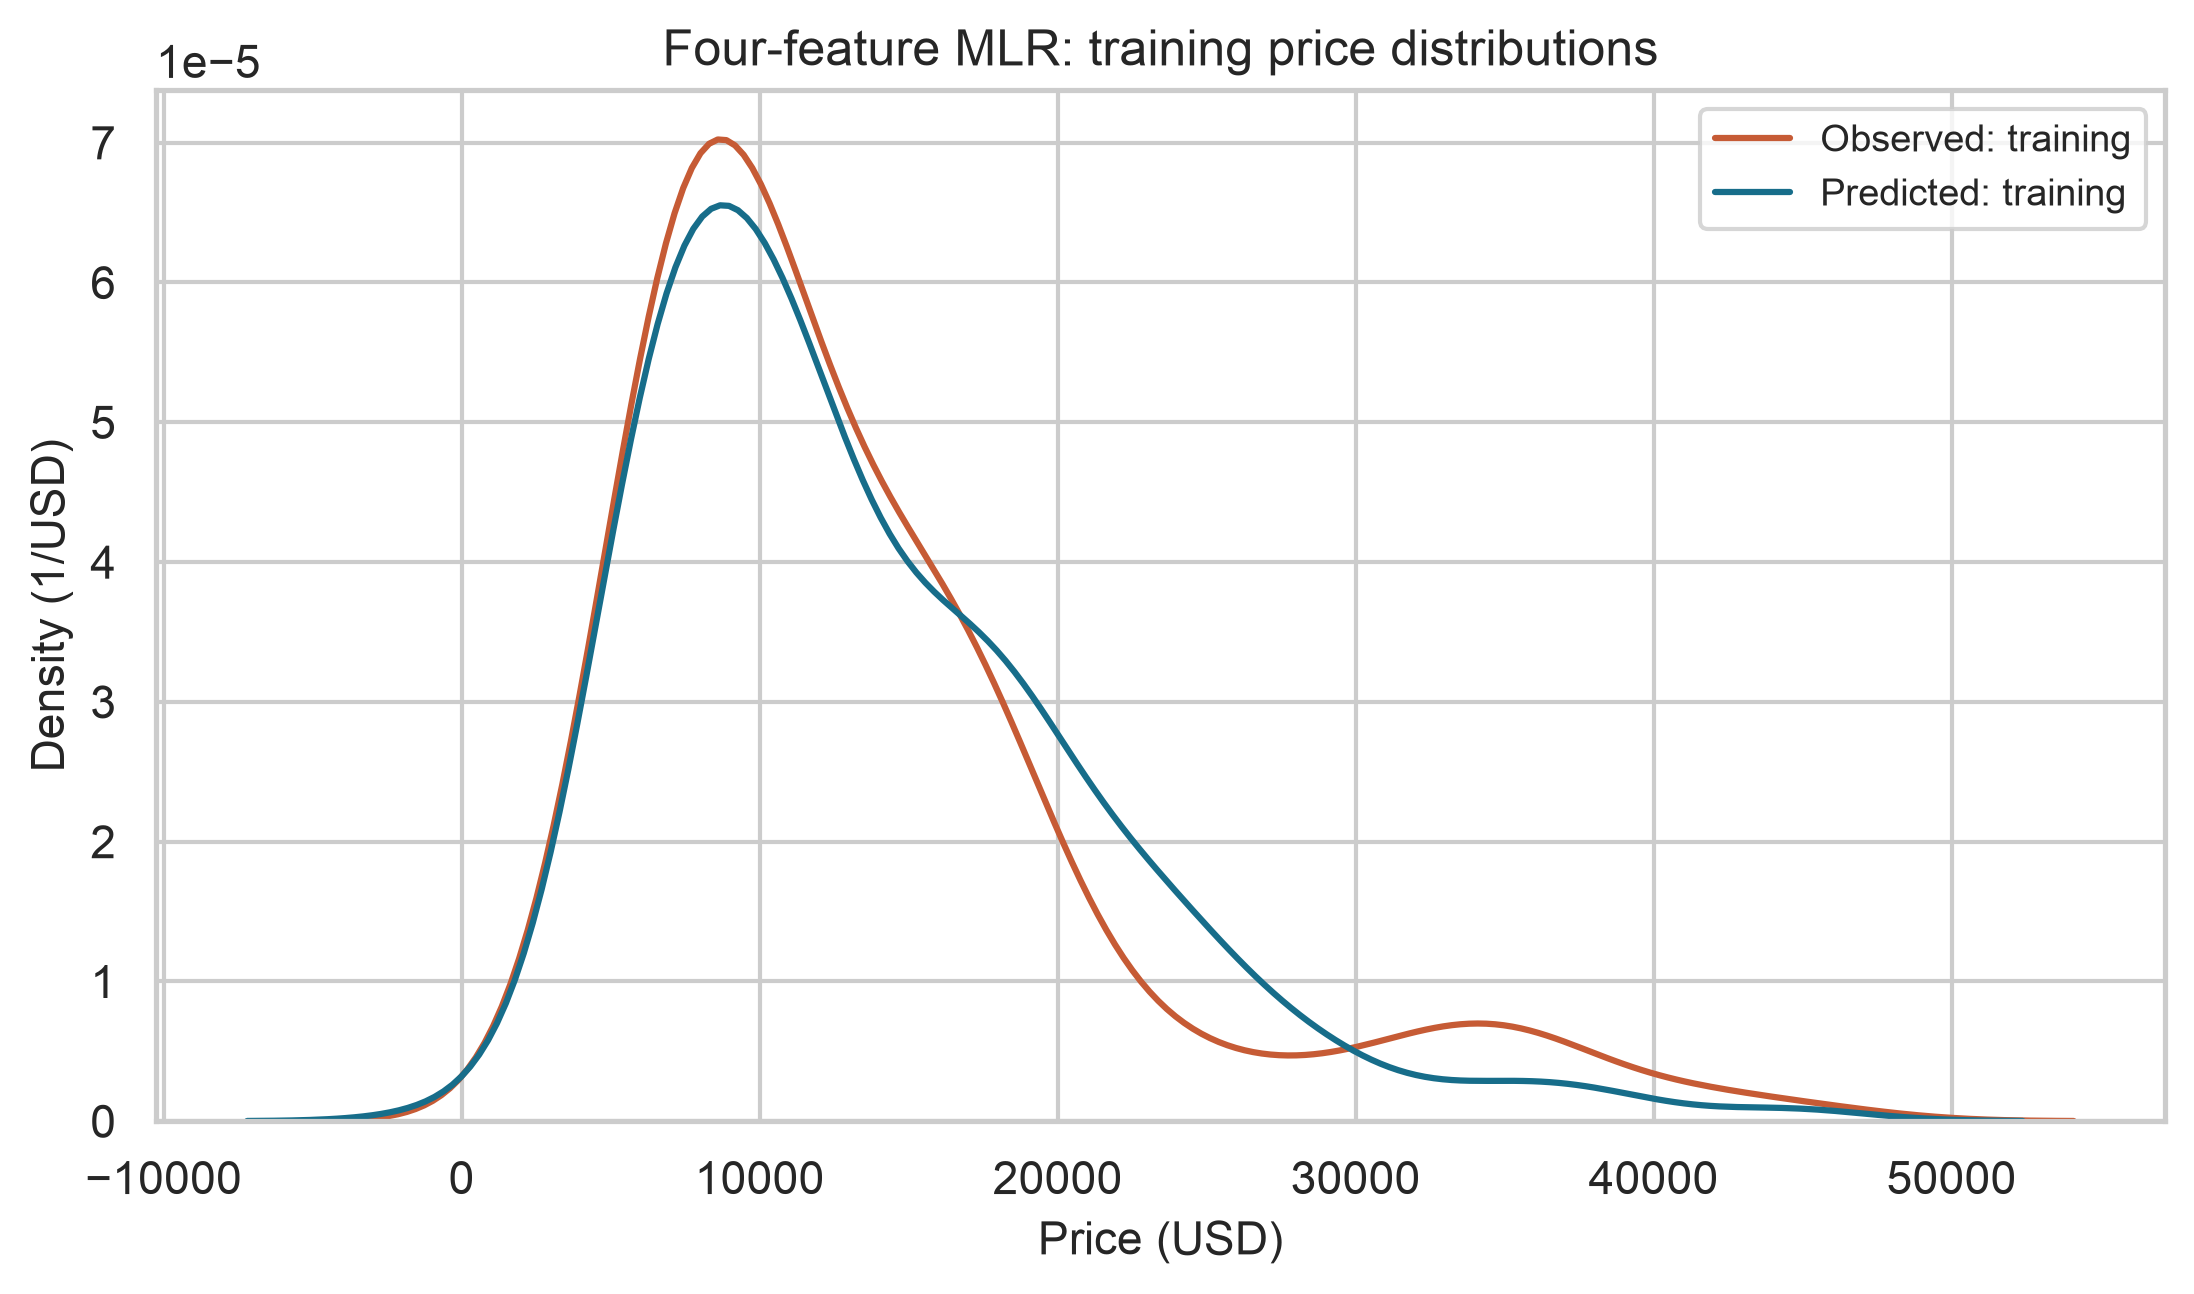

In [29]:
DistributionPlot(y_train,yhat_train,'Observed: training','Predicted: training','Four-feature MLR: training price distributions')

Figure 1: Plot of predicted values using the training data compared to the actual values of the training data. 


Compare the model’s marginal fitted-price distributions in the training and test subsets. Different density shapes can also reflect the small test sample; inspect paired metrics as well.

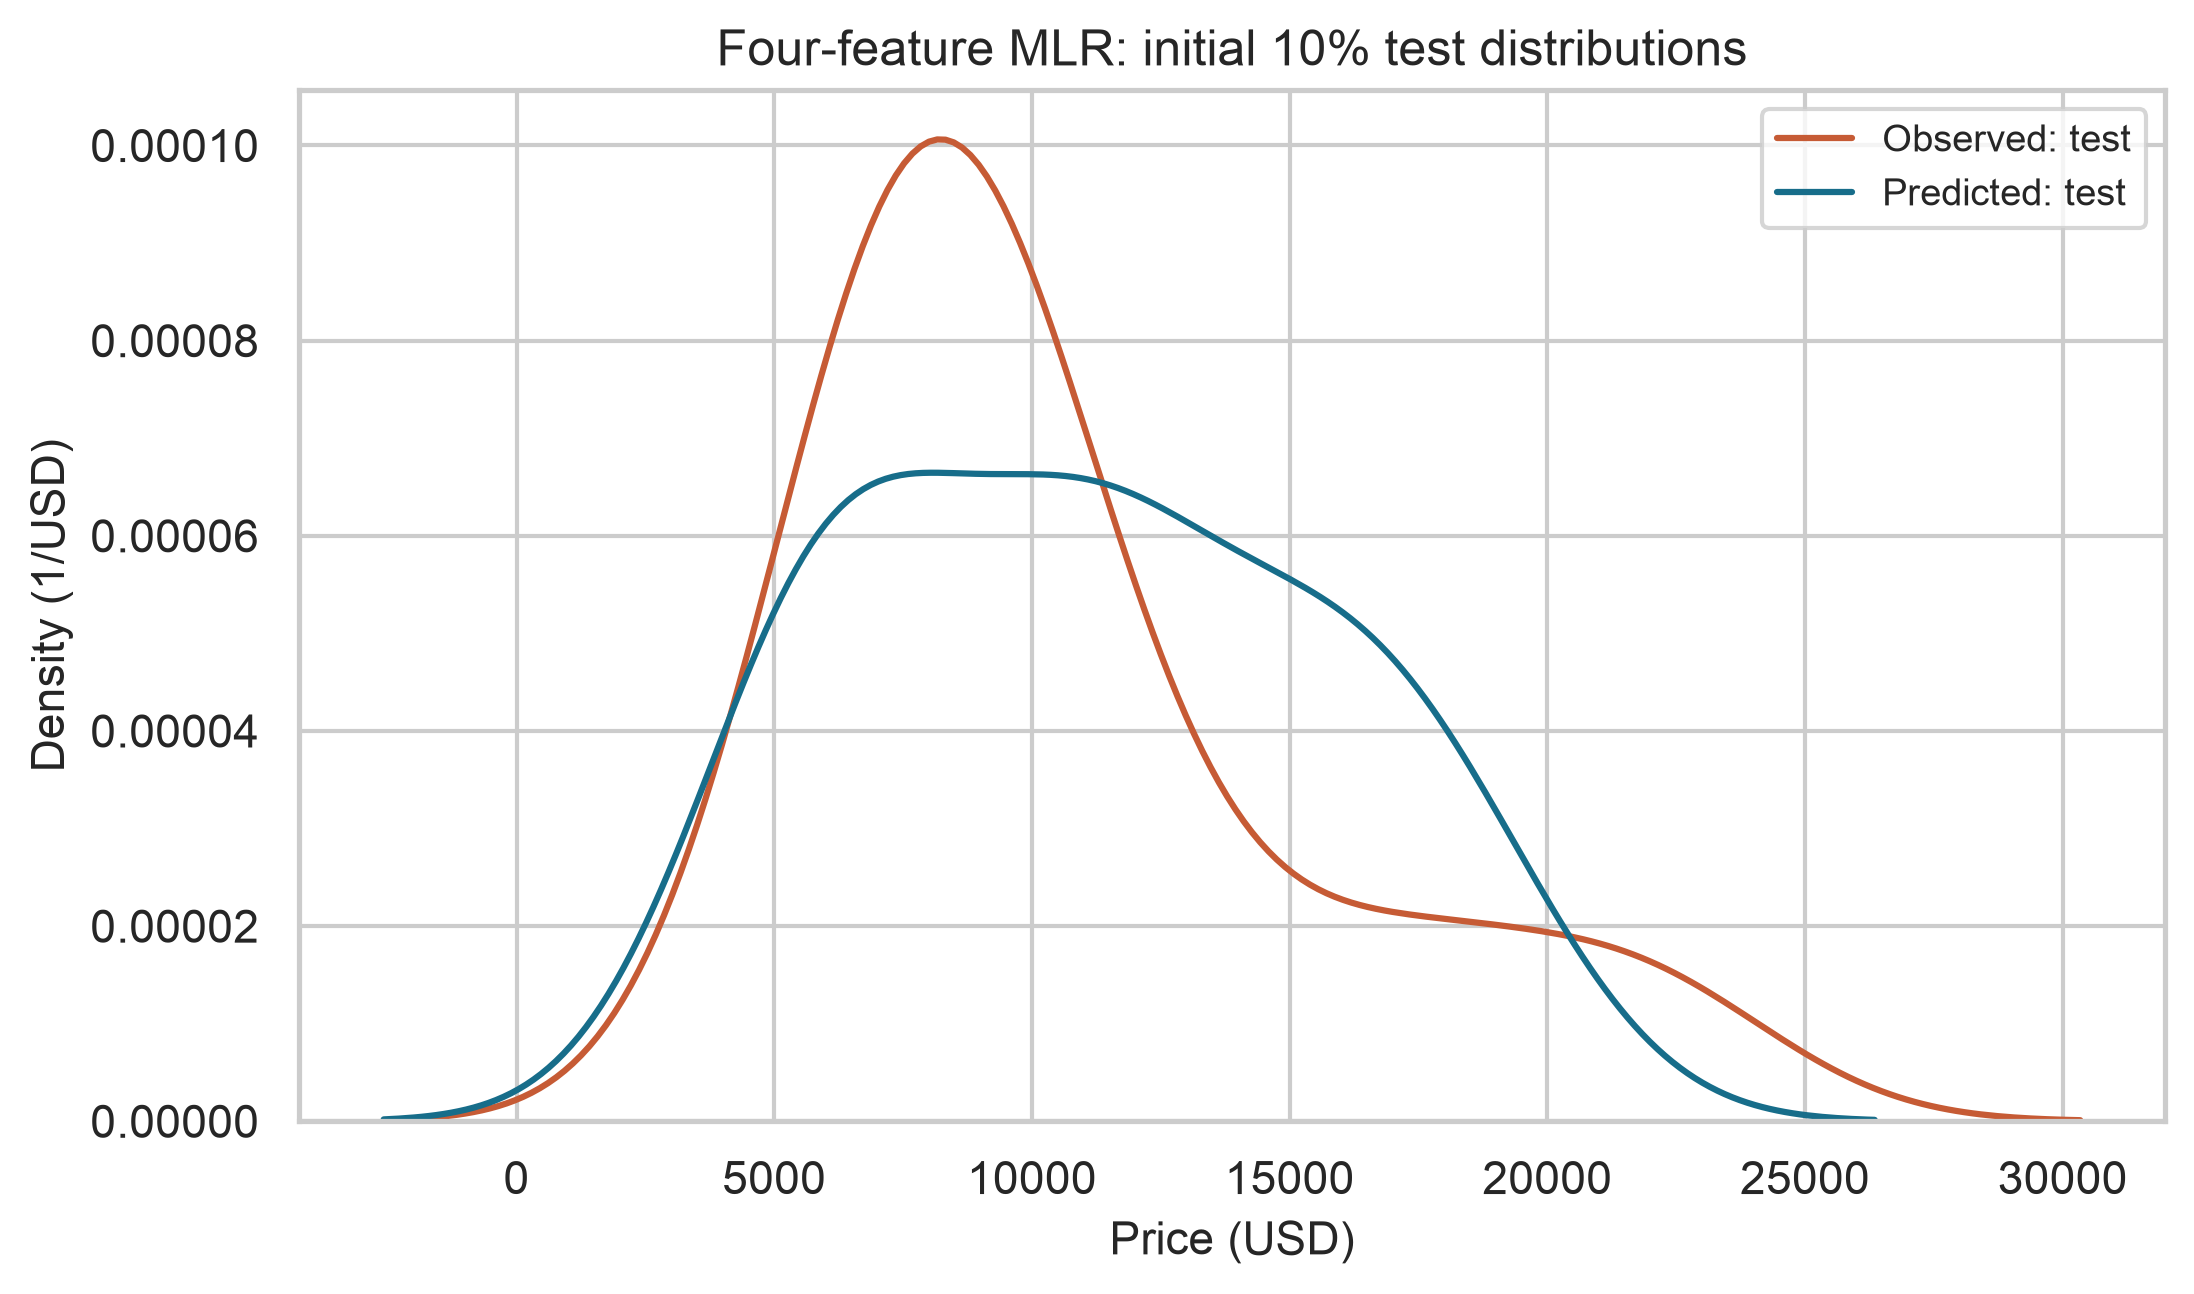

In [30]:
DistributionPlot(y_test,yhat_test,'Observed: test','Predicted: test','Four-feature MLR: initial 10% test distributions')

Figure 2: Plot of predicted value using the test data compared to the actual values of the test data. 


Figure 1 uses training data and Figure 2 uses the initial 10% test subset. Density overlap is not a per-observation error measure; the regenerated MLR metrics below provide that complementary check.

In [31]:
display(pd.DataFrame([metrics_row('MLR training',y_train,yhat_train),metrics_row('MLR initial 10% test',y_test,yhat_test)]).set_index('Model'))

,R²,MSE (USD²)
Model,,
MLR training,0.8142,1.2389e+07
MLR initial 10% test,0.6070,8.7009e+06


In [32]:
from sklearn.preprocessing import PolynomialFeatures

<h4>Overfitting</h4>
<p>Overfitting occurs when the model fits the noise, but not the underlying process. Therefore, when testing your model using the test set, your model does not perform as well since it is modelling noise, not the underlying process that generated the relationship. Let's create a degree 5 polynomial model.</p>


Let's use 55 percent of the data for training and the rest for testing:


In [33]:
x_train,x_test,y_train,y_test = train_test_split(x_data,y_data,test_size=0.45,random_state=0)
assert set(x_train.index).isdisjoint(x_test.index)
print(f'Development split (seed 0): training={len(x_train)}, validation={len(x_test)}')

Development split (seed 0): training=110, validation=91


We will perform a degree 5 polynomial transformation on the feature <b>'horsepower'</b>. 


In [34]:
pr = PolynomialFeatures(degree=5)
x_train_pr = pr.fit_transform(x_train[['horsepower']])
x_test_pr = pr.transform(x_test[['horsepower']])
print('Degree-5 matrices:',x_train_pr.shape,x_test_pr.shape)

Degree-5 matrices: (110, 6) (91, 6)


In scikit-learn 1.9, the dense LinearRegression tolerance defaults to 1e-6. On these unscaled powers, that threshold drops substantive polynomial directions. We use a machine-precision cutoff, `max(training_matrix.shape) × eps`, for raw polynomial least squares. The features, degree and split are unchanged; this numerical choice is based on the matrix dimensions, not validation performance.

Now, let's create a Linear Regression model "poly" and train it.


In [35]:
dense_tol = max(x_train_pr.shape) * np.finfo(float).eps
poly = LinearRegression(tol=dense_tol).fit(x_train_pr,y_train)
print(f'Dense least-squares tolerance: {dense_tol:.2e}; fitted rank: {poly.rank_}')

Dense least-squares tolerance: 2.44e-14; fitted rank: 5


We can see the output of our model using the method "predict." We assign the values to "yhat".


In [36]:
yhat = poly.predict(x_test_pr)
yhat[0:5]

array([ 6728.72239532,  7308.04778705, 12213.80433217, 18893.15624328,
       19995.84735794])

Let's take the first five predicted values and compare it to the actual targets. 


In [37]:
display(pd.DataFrame({'Observed (USD)':y_test.iloc[:5].to_numpy(),'Predicted (USD)':yhat[:5]}))

,Observed (USD),Predicted (USD)
0,6295.0,6728.7224
1,10698.0,7308.0478
2,13860.0,12213.8043
3,13499.0,18893.1562
4,15750.0,19995.8474


We will use the function "PollyPlot" that we defined at the beginning of the lab to display the training data, testing data, and the predicted function.


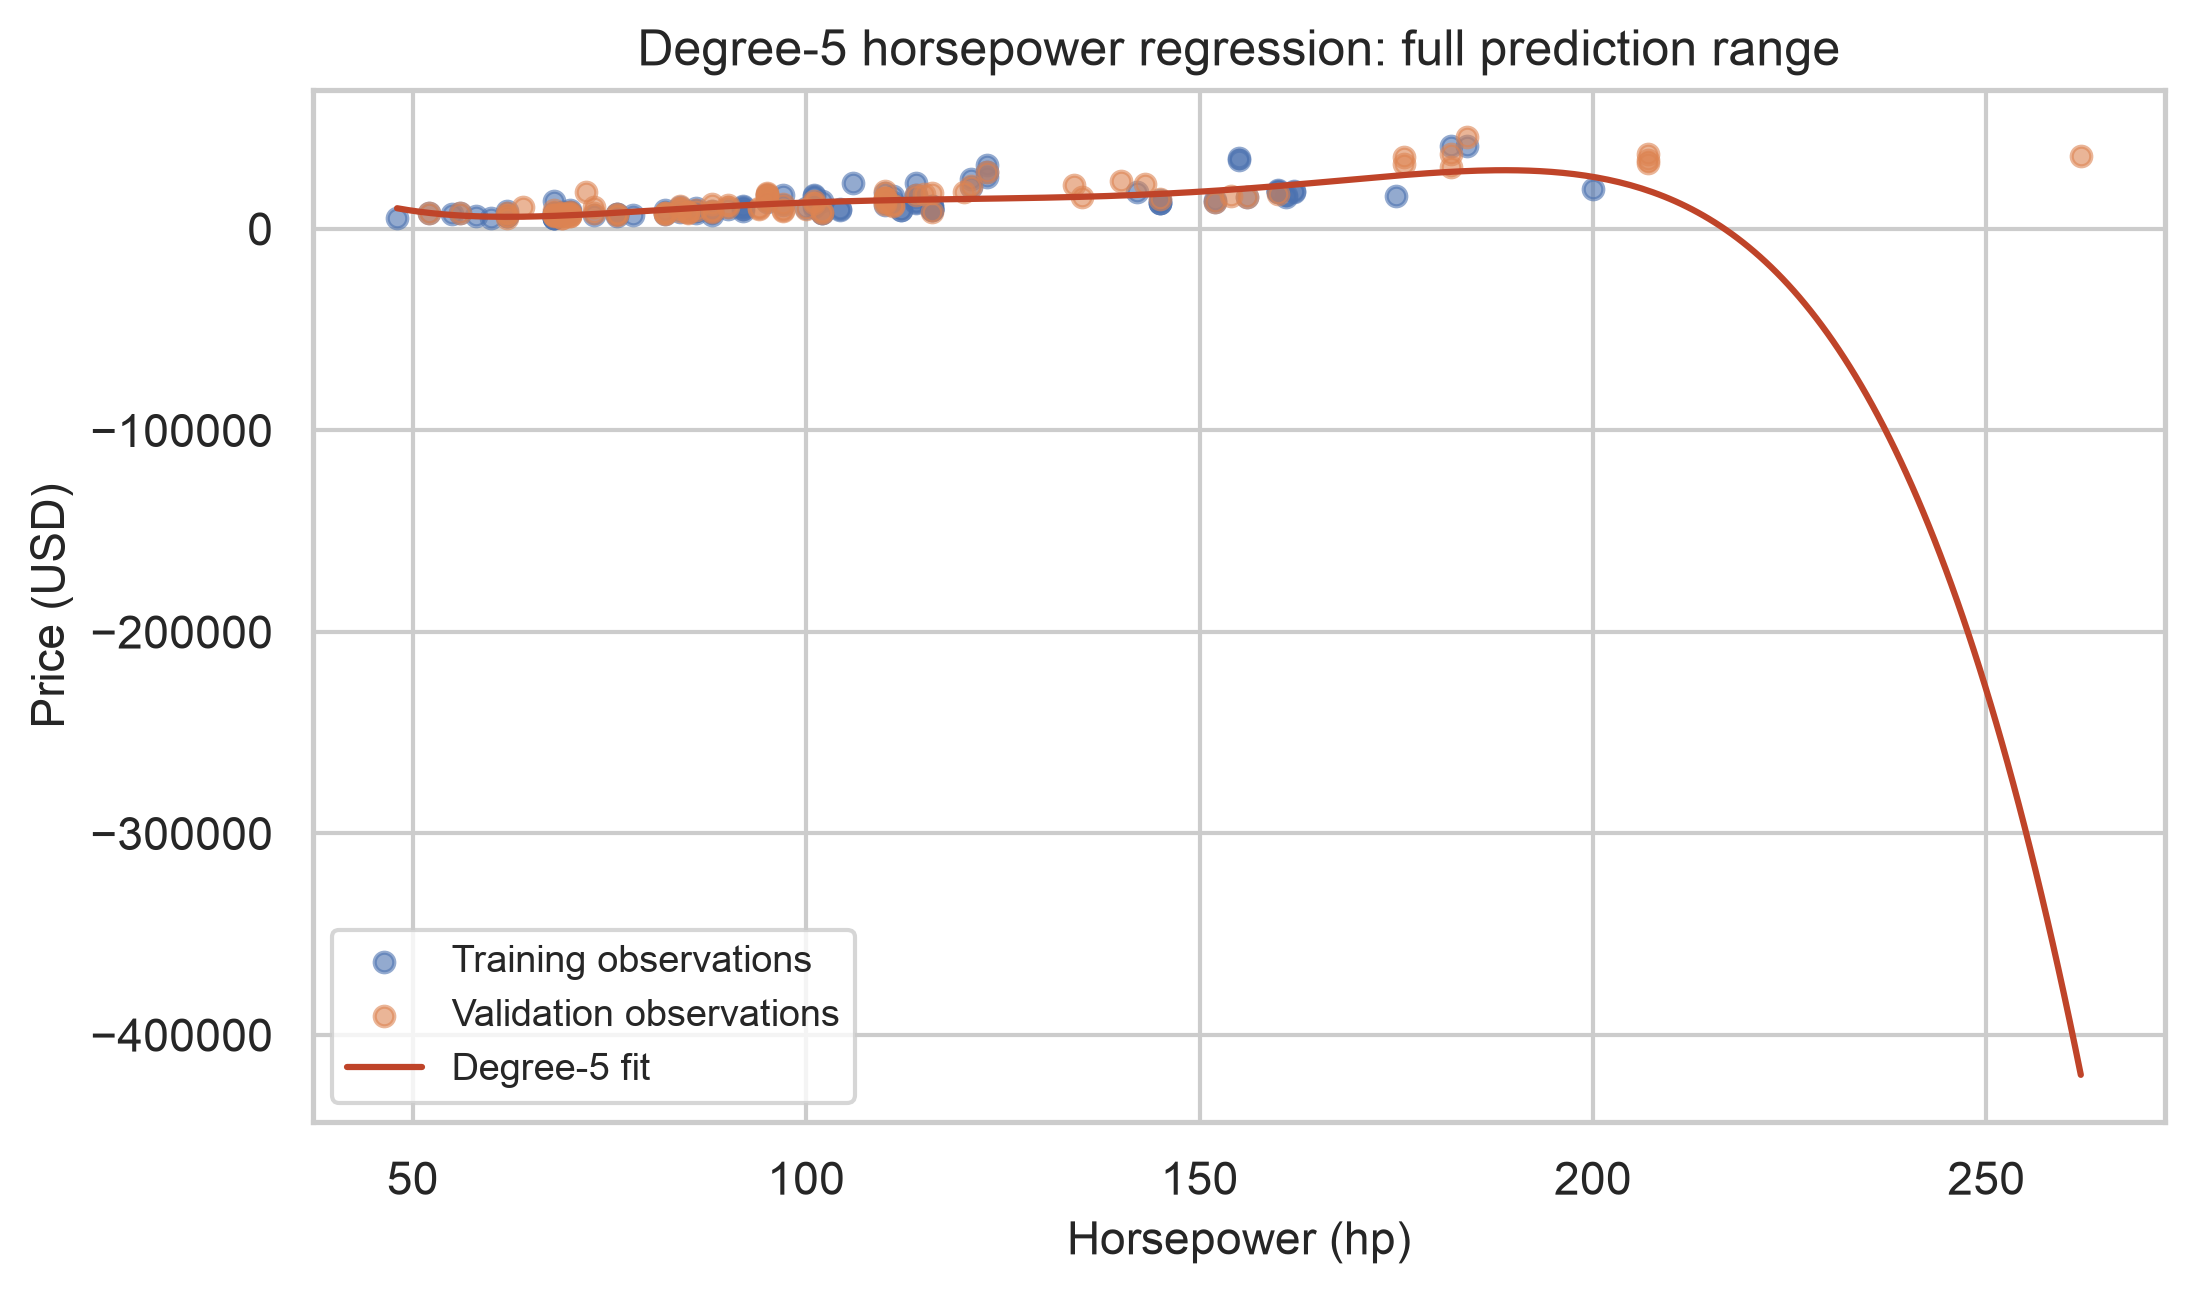

In [38]:
PollyPlot(x_train['horsepower'], x_test['horsepower'], y_train, y_test, poly,pr)

Figure 3 shows the training observations, development-validation observations and fitted degree-5 curve, identified by the legend. The curve is shown over the full observed horsepower range.

The degree-5 curve can vary sharply near sparse or out-of-training-range horsepower values. Inspect the full plotted range and the two measured R² values.

 R^2 of the training data:


In [39]:
degree5_train = poly.score(x_train_pr,y_train)
print(f'Degree-5 training R²: {degree5_train:.6f}')

Degree-5 training R²: 0.556772


 R^2 of the test data:


In [40]:
degree5_validation = poly.score(x_test_pr,y_test)
print(f'Degree-5 validation R²: {degree5_validation:.6f}')

Degree-5 validation R²: -29.871481


In [41]:
print(f'Training versus validation R² gap: {degree5_train-degree5_validation:.3f}')
print('The fitted curve and the measured training/validation discrepancy warn against using degree 5 for prediction.')

Training versus validation R² gap: 30.428
The fitted curve and the measured training/validation discrepancy warn against using degree 5 for prediction.


Negative validation R² means squared error exceeds the benchmark based on that validation set’s target mean. In combination with the training/validation discrepancy and edge instability, it diagnoses poor generalization here; negative R² alone is not a universal proof of overfitting.

Let's see how the R^2 changes on the test data for different order polynomials and then plot the results:


,Training R²,Validation R²
Degree,,
1,0.5325,0.7325
2,0.5330,0.7406
3,0.5330,0.7406
4,0.5352,0.4064


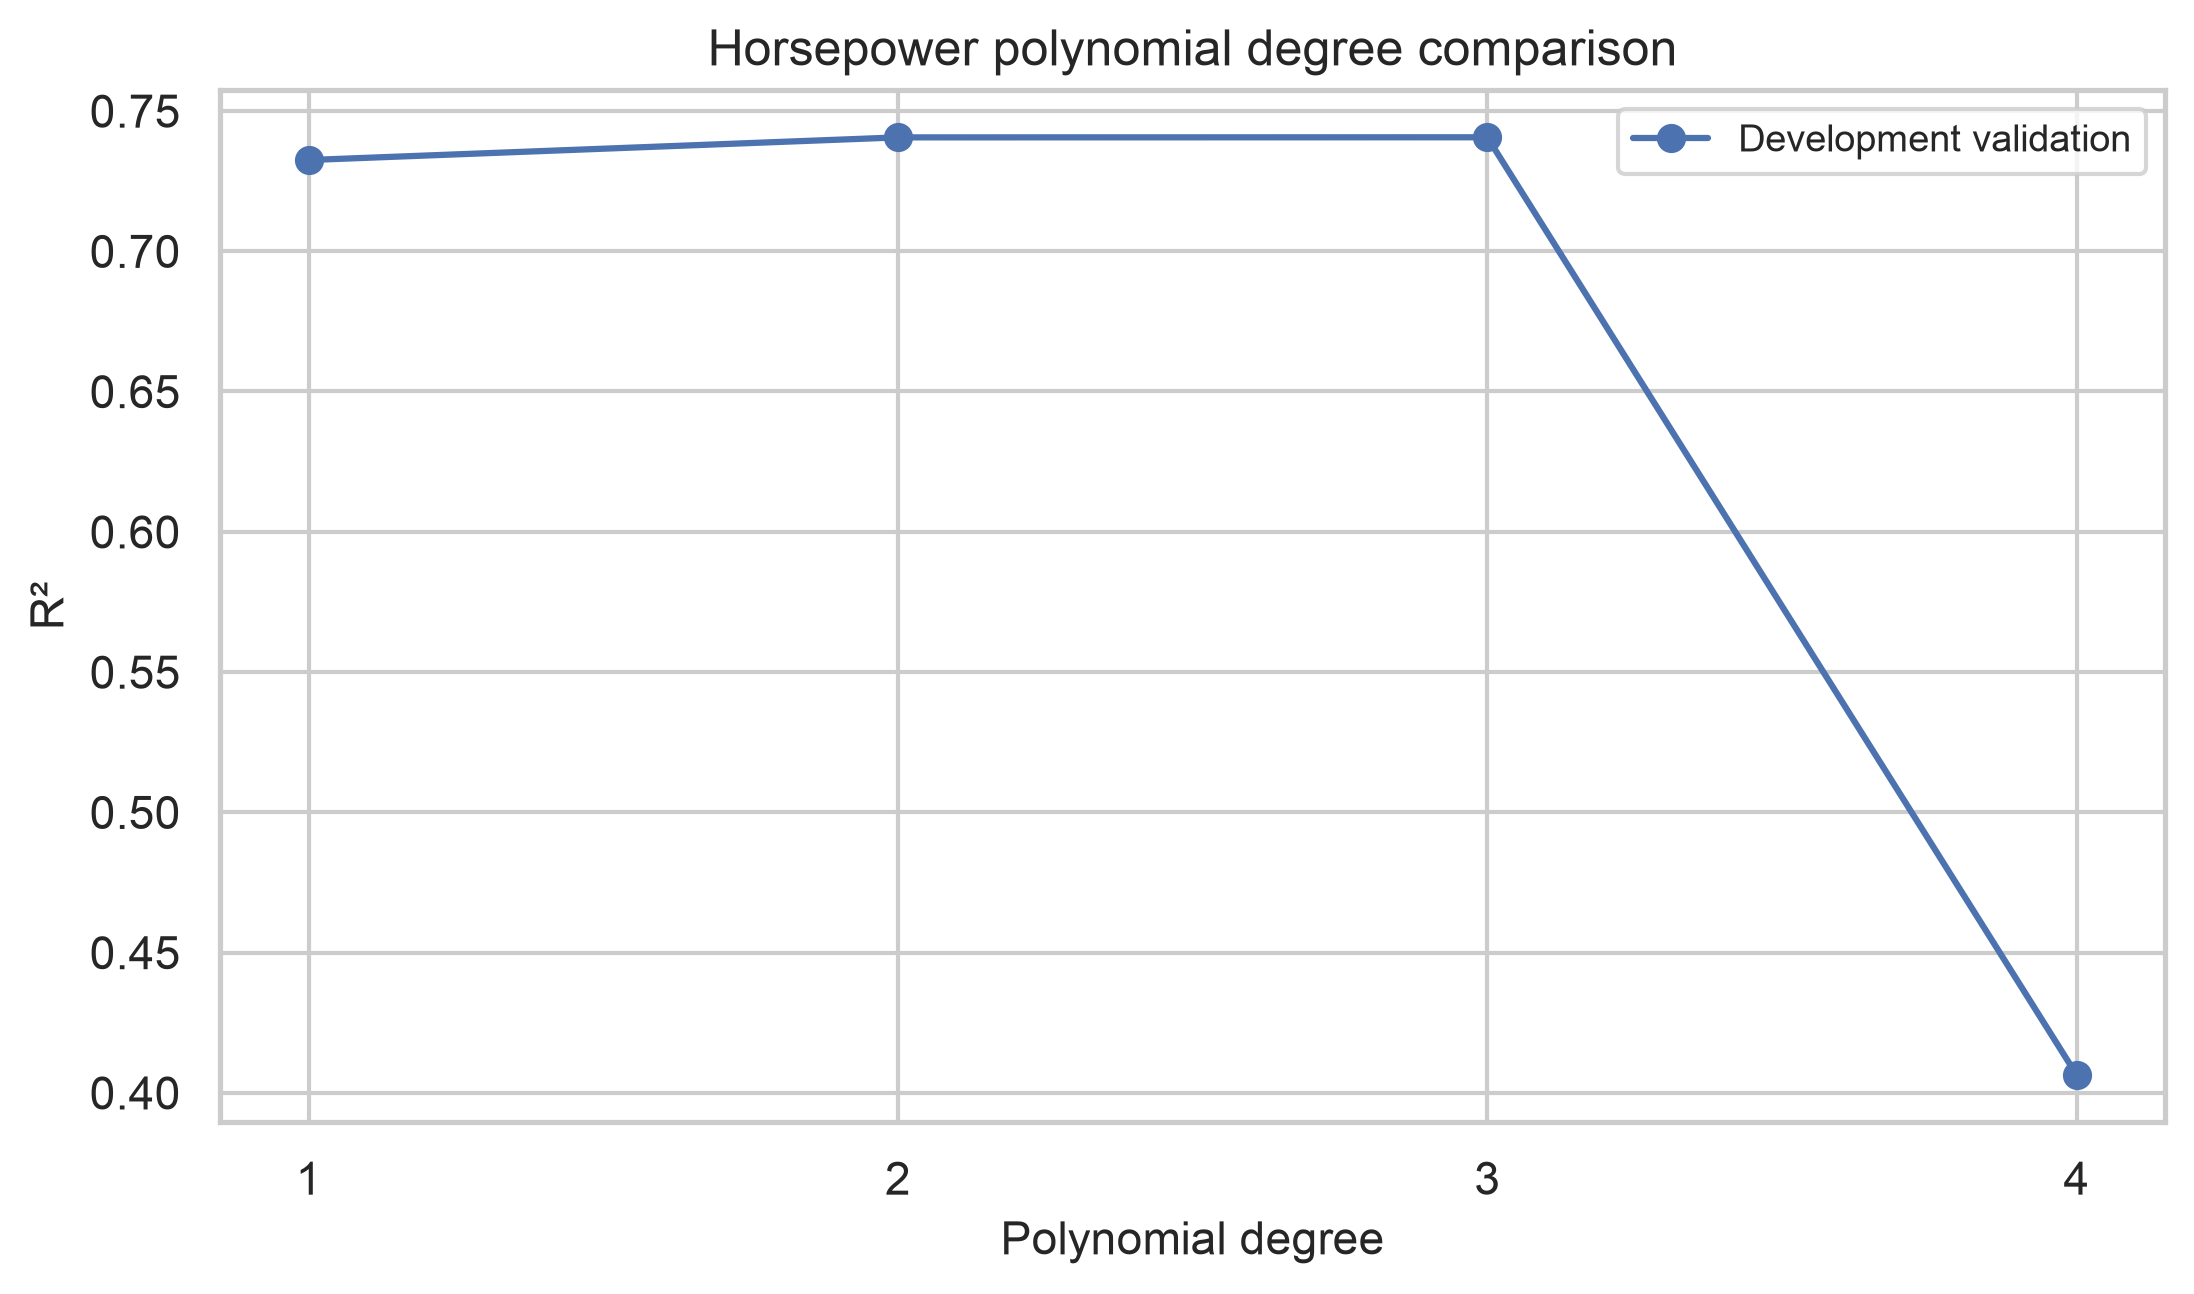

Largest validation R² among degrees 1–4: degree 3.


In [42]:
order = [1,2,3,4]
Rsqu_test, degree_train_scores = [], []
for n in order:
    pr = PolynomialFeatures(degree=n)
    x_train_pr = pr.fit_transform(x_train[['horsepower']])
    x_test_pr = pr.transform(x_test[['horsepower']])
    dense_tol = max(x_train_pr.shape) * np.finfo(float).eps
    lr = LinearRegression(tol=dense_tol).fit(x_train_pr,y_train)
    Rsqu_test.append(lr.score(x_test_pr,y_test))
    degree_train_scores.append(lr.score(x_train_pr,y_train))
display(pd.DataFrame({'Degree':order,'Training R²':degree_train_scores,'Validation R²':Rsqu_test}).set_index('Degree'))
fig, ax = plt.subplots()
ax.plot(order,Rsqu_test,'o-',label='Development validation')
ax.set(title='Horsepower polynomial degree comparison',xlabel='Polynomial degree',ylabel='R²',xticks=order)
ax.legend()
plt.show()
print(f'Largest validation R² among degrees 1–4: degree {order[int(np.argmax(Rsqu_test))]}.')

The measured degree comparison is printed with the plot. These four scores are model-development diagnostics from repeated use of the same validation subset.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question  #4a):</h1>

<b>We can perform polynomial transformations with more than one feature. Create a "PolynomialFeatures" object "pr1" of degree two.</b>
</div>


In [43]:
pr1 = PolynomialFeatures(degree=2)
pr1

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


### Question #4b
Transform the training and testing samples for horsepower, curb-weight, engine-size and highway-mpg.

Fit `pr1` on training data and use `transform` for validation. PolynomialFeatures does not learn a distribution, but this consistent pattern avoids refitting the transformer on evaluation inputs.

In [44]:
x_train_pr1 = pr1.fit_transform(x_train[features4])
x_test_pr1 = pr1.transform(x_test[features4])

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question  #4c): </h1>
<b> 
How many dimensions does the new feature have? Hint: use the attribute "shape".
</b>
</div>


In [45]:
print('Training shape:',x_train_pr1.shape)
print('Validation shape:',x_test_pr1.shape)
print('15 columns = 1 constant + 4 original predictors + 10 quadratic terms.')

Training shape: (110, 15)
Validation shape: (91, 15)
15 columns = 1 constant + 4 original predictors + 10 quadratic terms.


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question  #4d): </h1>

<b> 
Create a linear regression model "poly1". Train the object using the method "fit" using the polynomial features.</b>
</div>


In [46]:
dense_tol = max(x_train_pr1.shape) * np.finfo(float).eps
poly1 = LinearRegression(tol=dense_tol).fit(x_train_pr1,y_train)
print(f'Q4 fitted rank: {poly1.rank_}; training R²: {poly1.score(x_train_pr1,y_train):.6f}')

Q4 fitted rank: 14; training R²: 0.853056


 <div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question  #4e): </h1>
<b>Use the method  "predict" to predict an output on the polynomial features, then use the function "DistributionPlot" to display the distribution of the predicted test output vs. the actual test data.</b>
</div>


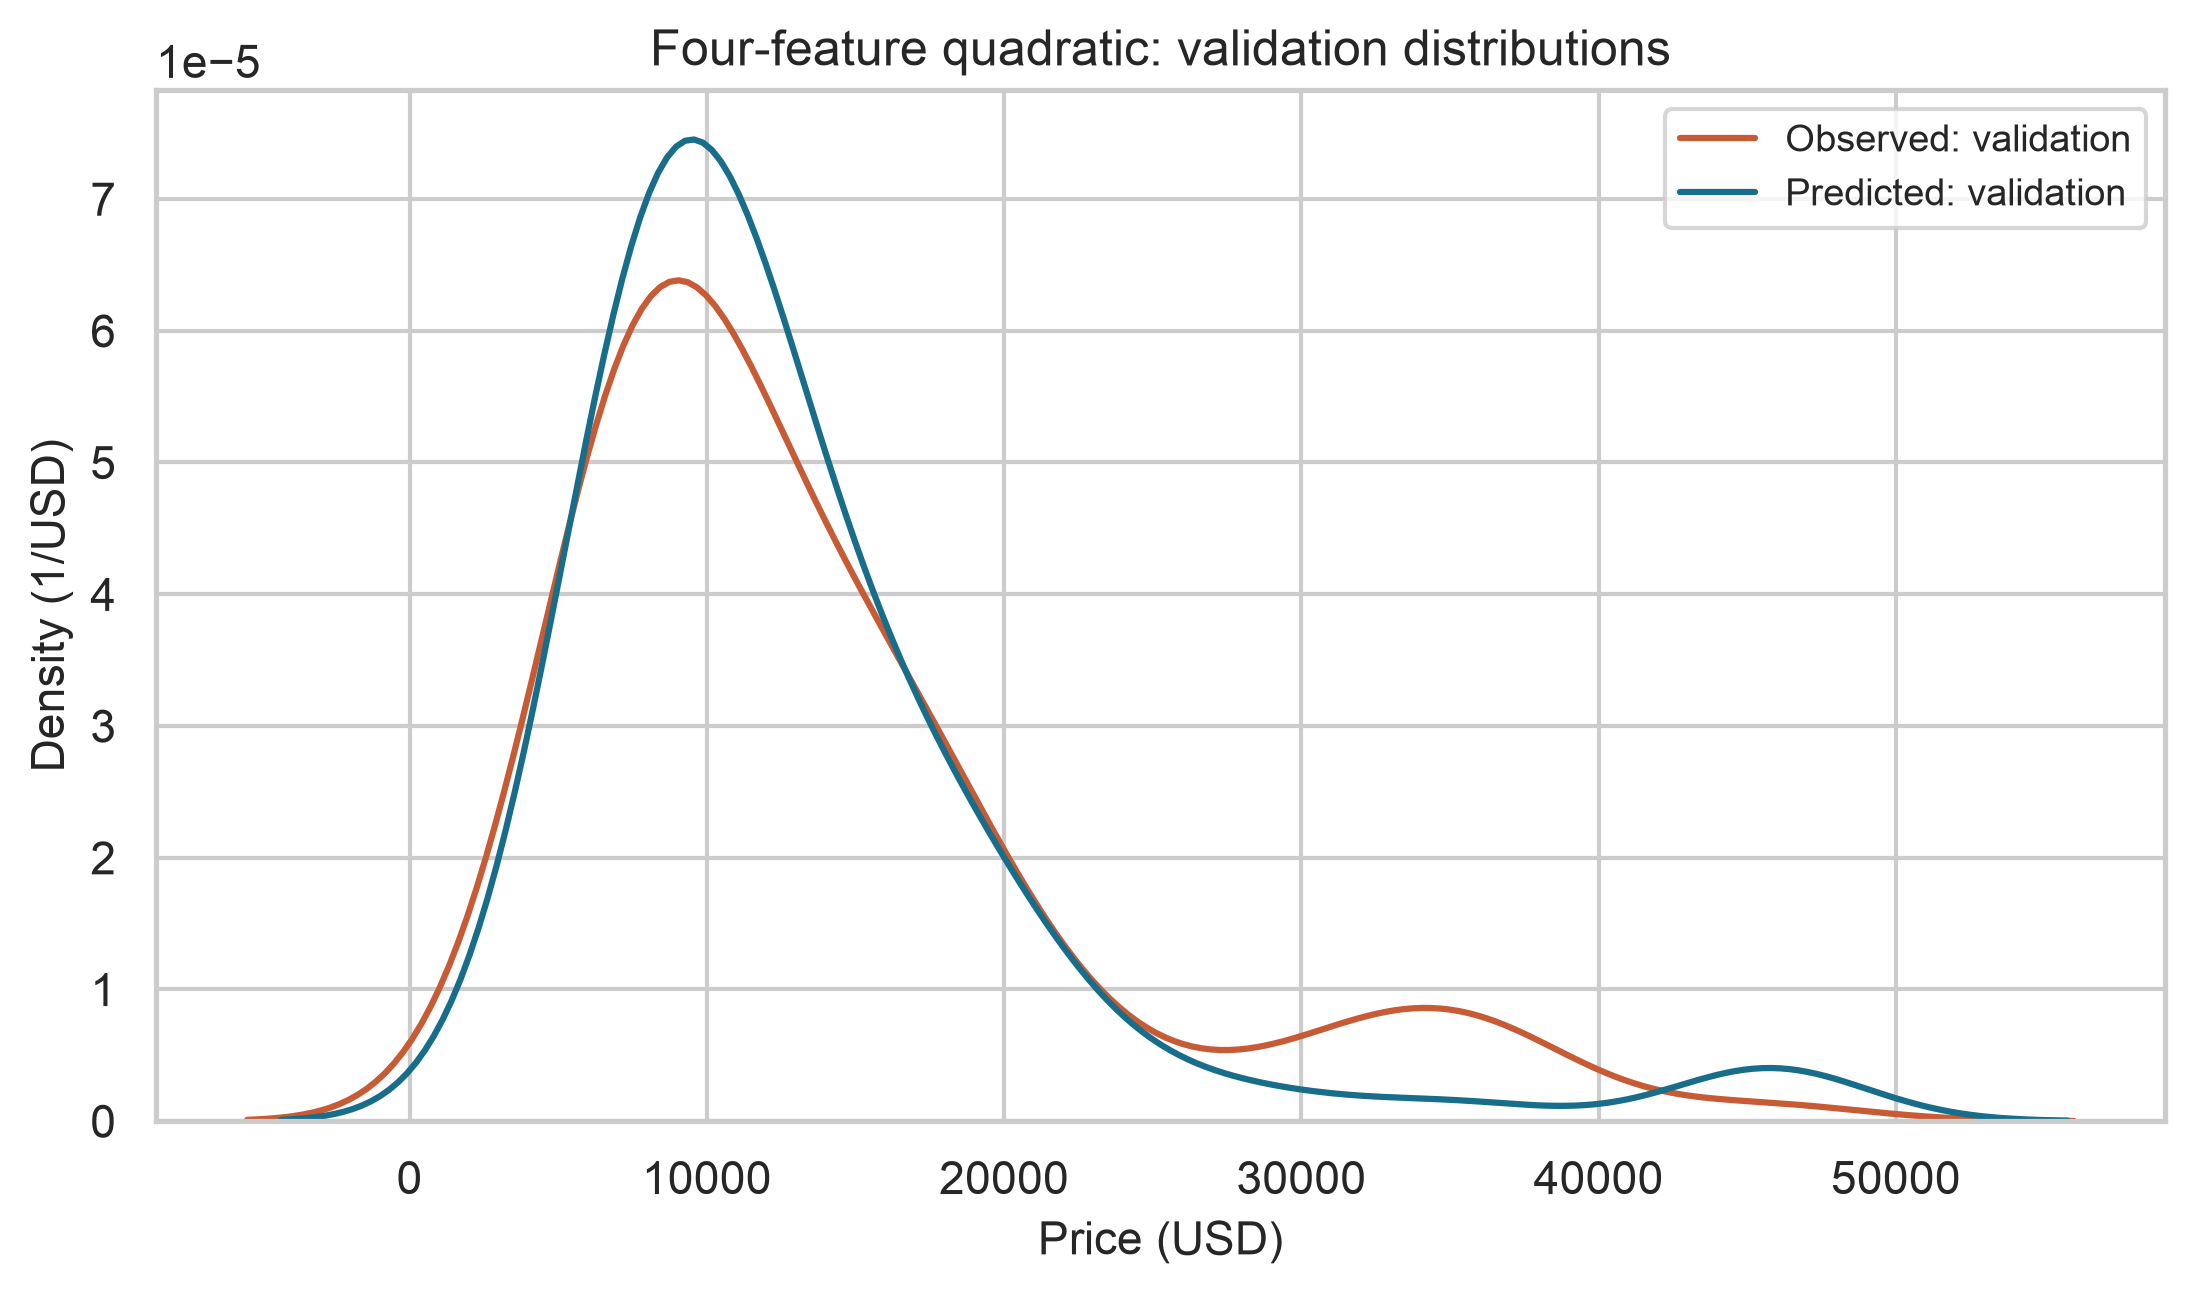

Q4 validation R²: 0.604507


In [47]:
yhat_q4 = poly1.predict(x_test_pr1)
DistributionPlot(y_test,yhat_q4,'Observed: validation','Predicted: validation','Four-feature quadratic: validation distributions')
print(f'Q4 validation R²: {r2_score(y_test,yhat_q4):.6f}')

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question  #4f): </h1>

<b>Using the distribution plot above, describe (in words) the two regions where the predicted prices are less accurate than the actual prices.</b>
</div>


In [48]:
price_regions = pd.cut(y_test,[0,10000,30000,np.inf],labels=['Below $10,000','$10,000–30,000','Above $30,000'])
region_error = pd.DataFrame({'Region':price_regions,'Observed':y_test,
                            'Predicted':yhat_q4,'Absolute error':np.abs(y_test-yhat_q4)})
region_summary = region_error.groupby('Region',observed=True).agg(
    n=('Observed','size'),observed_mean=('Observed','mean'),
    predicted_mean=('Predicted','mean'),MAE_USD=('Absolute error','mean'))
display(region_summary)
low, high = region_summary.iloc[0],region_summary.iloc[-1]
print(f'Below $10,000, mean predicted price exceeds mean observed price by '
      f"${low['predicted_mean']-low['observed_mean']:,.0f}; the fitted low-price density is too peaked.")
print(f'Above $30,000, mean price is underpredicted by '
      f"${high['observed_mean']-high['predicted_mean']:,.0f}, with MAE ${high['MAE_USD']:,.0f} across {int(high['n'])} cars.")
print('The sparse high-price tail has much larger paired errors; density overlap alone cannot locate individual errors.')

,n,observed_mean,predicted_mean,MAE_USD
Region,,,,
"Below $10,000",42,7684.2381,8096.1535,736.2968
"$10,000–30,000",40,15508.9000,14676.1218,2683.4362
"Above $30,000",9,35602.6667,28799.0563,14240.8750


Below $10,000, mean predicted price exceeds mean observed price by $412; the fitted low-price density is too peaked.
Above $30,000, mean price is underpredicted by $6,804, with MAE $14,241 across 9 cars.
The sparse high-price tail has much larger paired errors; density overlap alone cannot locate individual errors.


<h2 id="ref3">Part 3: Ridge Regression</h2> 


 In this section, we will review Ridge Regression and see how the parameter alpha changes the model. Just a note, here our test data will be used as validation data.


 Let's perform a degree two polynomial transformation on our data. 


In [49]:
features6 = features4 + ['normalized-losses','symboling']
pr = PolynomialFeatures(degree=2)
x_train_pr_full = pr.fit_transform(x_train[features6])
x_test_pr_full = pr.transform(x_test[features6])
print('Six-feature degree-2 matrices:',x_train_pr_full.shape,x_test_pr_full.shape)
assert np.all(x_train_pr_full[:,0] == 1)
x_train_pr = x_train_pr_full[:,1:]
x_test_pr = x_test_pr_full[:,1:]
print('Ridge inputs after removing redundant constant:',x_train_pr.shape,x_test_pr.shape)

Six-feature degree-2 matrices: (110, 28) (91, 28)
Ridge inputs after removing redundant constant: (110, 27) (91, 27)


The expansion first includes the required constant column. Ridge already fits an unpenalized intercept, so the duplicate constant is removed before fitting. This preserves the represented model and penalty while avoiding a numerically singular centered column, especially at alpha zero.

 Let's import  <b>Ridge</b>  from the module <b>linear models</b>.


In [50]:
from sklearn.linear_model import Ridge

Let's create a Ridge regression object, setting the regularization parameter (alpha) to 1 


In [51]:
# SVD solves the same Ridge objective more stably for unscaled polynomial features.
RigeModel = Ridge(alpha=1,solver='svd')

The prescribed raw polynomial terms have widely different magnitudes. `solver="svd"` changes the numerical solver, not the Ridge loss or alpha values; it avoids relying on an ill-conditioned normal-equation solve. The full required sweep includes alpha zero (no penalty).

Like regular regression, you can fit the model using the method <b>fit</b>.


In [52]:
RigeModel.fit(x_train_pr, y_train)

,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'svd'
,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to 

 Similarly, you can obtain a prediction: 


In [53]:
yhat = RigeModel.predict(x_test_pr)

Let's compare the first four predicted samples to our test set: 


In [54]:
display(pd.DataFrame({'Observed (USD)':y_test.iloc[:4].to_numpy(),'Predicted (USD)':yhat[:4]}))
print(f'Alpha 1: training R²={RigeModel.score(x_train_pr,y_train):.6f}; validation R²={RigeModel.score(x_test_pr,y_test):.6f}')

,Observed (USD),Predicted (USD)
0,6295.0,6570.8244
1,10698.0,9636.2489
2,13860.0,20949.9232
3,13499.0,19403.6031


Alpha 1: training R²=0.870977; validation R²=0.533427


Evaluate the full prescribed alpha grid, 0, 10, …, 9990. Because we compare 1,000 settings on the same excluded subset, its scores are validation diagnostics. They do not constitute an untouched final-test claim.

In [55]:
from tqdm import tqdm
Rsqu_test, Rsqu_train = [], []
Alpha = 10 * np.arange(1000)
for alpha in tqdm(Alpha,desc='Required 1,000 Ridge settings',mininterval=2):
    RigeModel = Ridge(alpha=float(alpha),solver='svd').fit(x_train_pr,y_train)
    Rsqu_test.append(RigeModel.score(x_test_pr,y_test))
    Rsqu_train.append(RigeModel.score(x_train_pr,y_train))
ridge_curve = pd.DataFrame({'alpha':Alpha,'Training R²':Rsqu_train,'Validation R²':Rsqu_test})
print(f'Completed {len(Alpha)} settings, from {Alpha[0]} through {Alpha[-1]}, step 10.')
display(ridge_curve.iloc[[0,1,100,500,999]])

Required 1,000 Ridge settings:   0%|          | 0/1000 [00:00<?, ?it/s]

Required 1,000 Ridge settings: 100%|██████████| 1000/1000 [00:00<00:00, 1082.20it/s]

Completed 1000 settings, from 0 through 9990, step 10.


,alpha,Training R²,Validation R²
0,0,0.8711,0.5223
1,10,0.8707,0.5419
100,1000,0.8613,0.5397
500,5000,0.8598,0.5532
999,9990,0.8593,0.5638


We can plot out the value of R^2 for different alphas: 


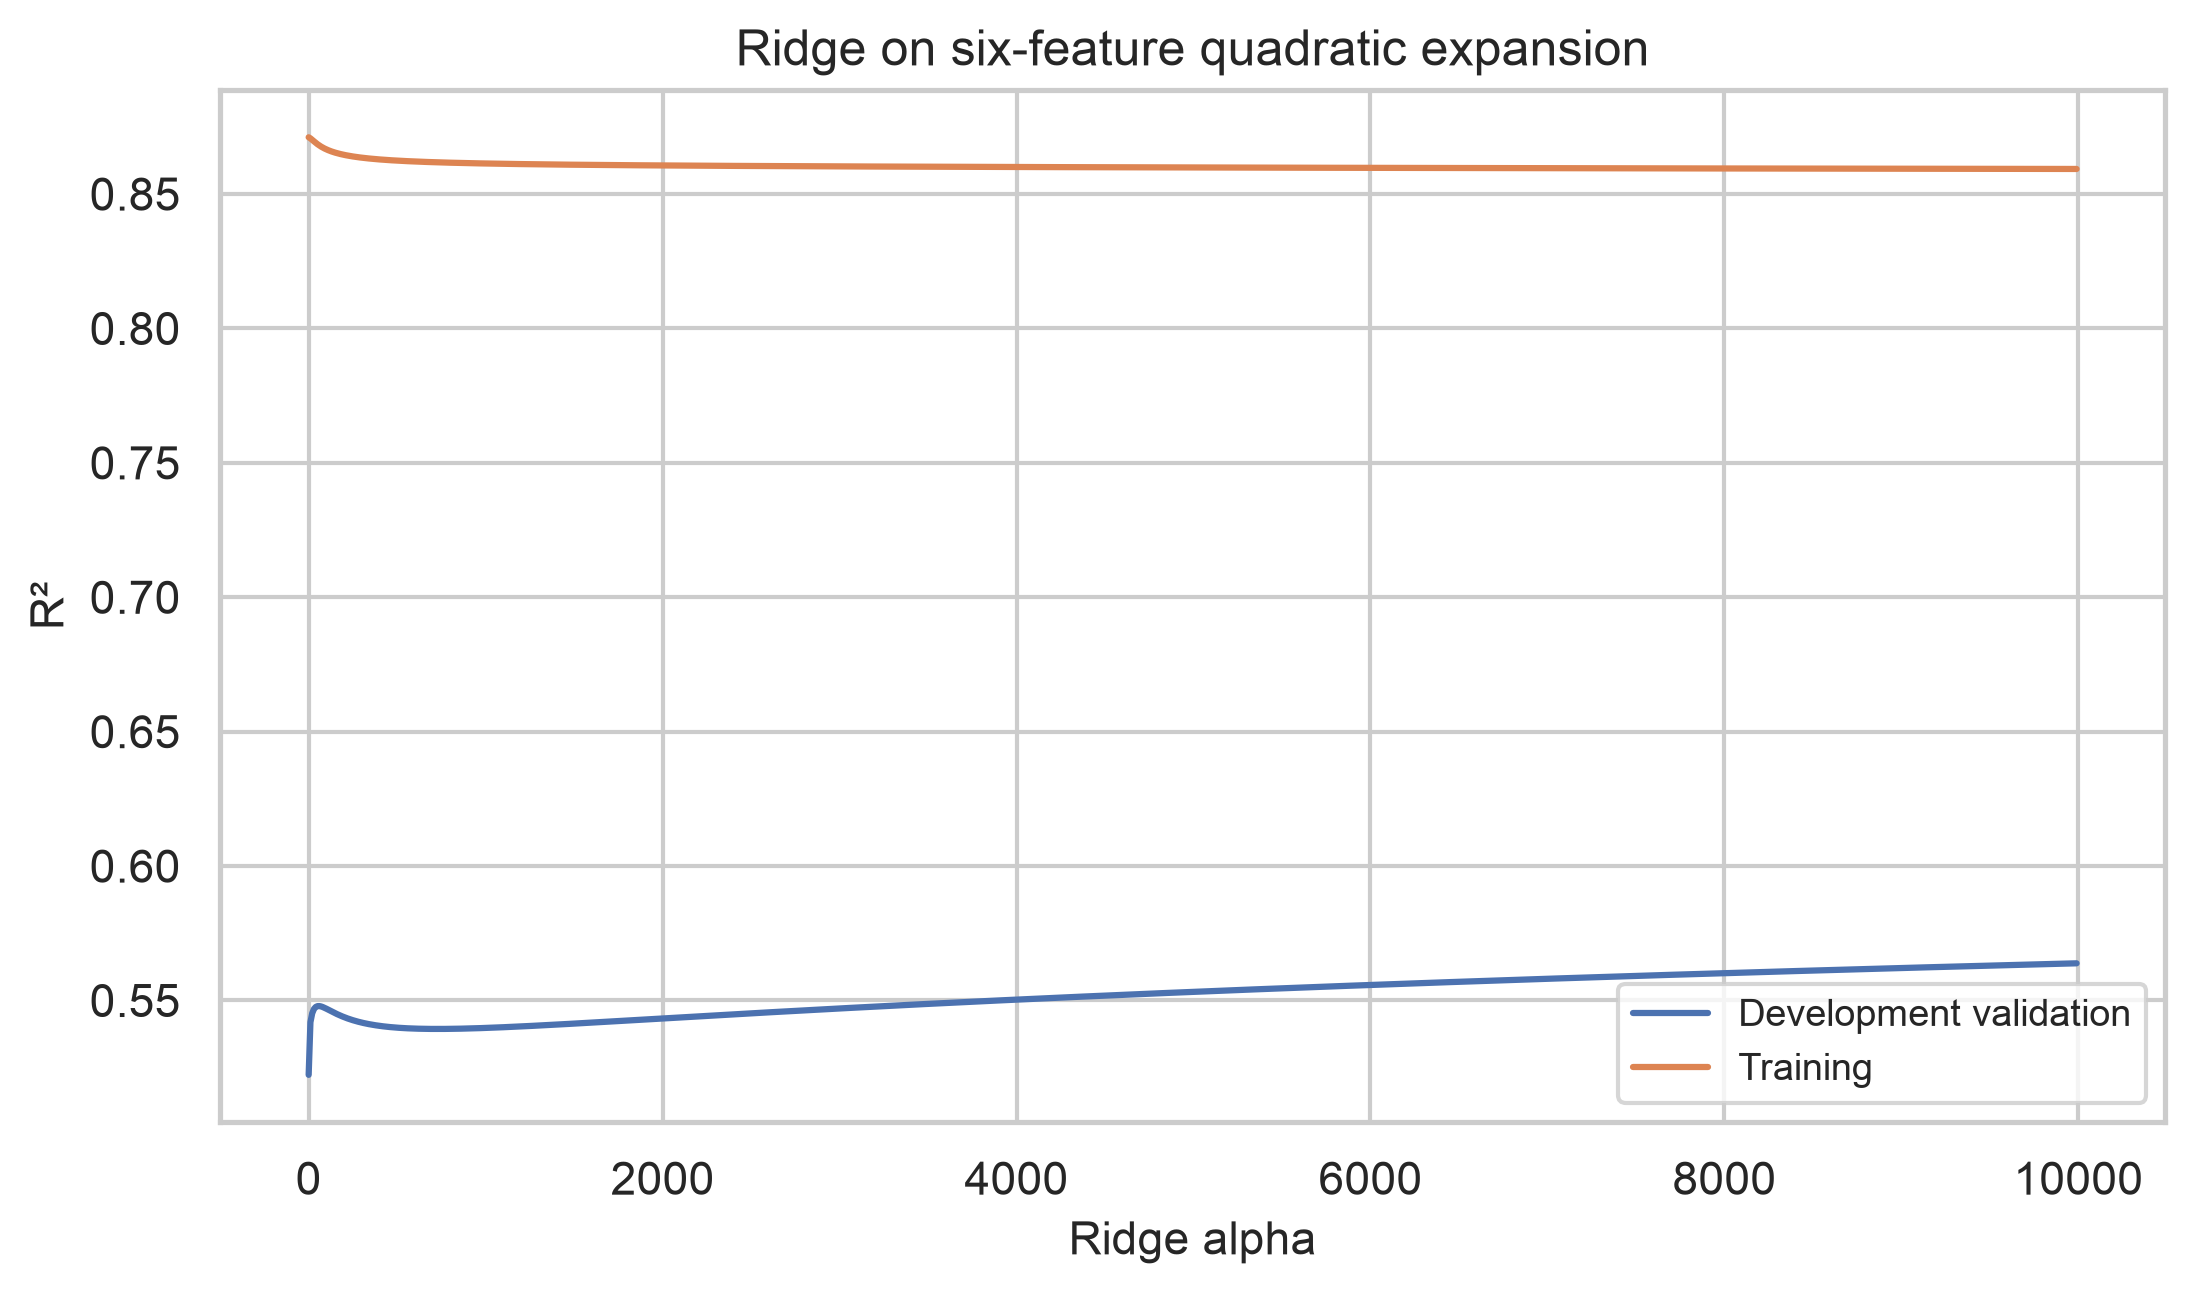

Largest inspected validation R²: 0.563770 at alpha=9990.


In [56]:
fig, ax = plt.subplots()
ax.plot(Alpha,Rsqu_test,label='Development validation')
ax.plot(Alpha,Rsqu_train,label='Training')
ax.set(title='Ridge on six-feature quadratic expansion',xlabel='Ridge alpha',ylabel='R²')
ax.legend()
plt.show()
best_i = int(np.argmax(Rsqu_test))
print(f'Largest inspected validation R²: {Rsqu_test[best_i]:.6f} at alpha={Alpha[best_i]}.')

**Figure 4** compares training and development-validation R² across the prescribed Ridge alpha values. The legend identifies the two curves.

Training and validation subsets are disjoint. The curves show how the fitted model and its validation behavior change with alpha; the data are not the same in the two curves. Raw polynomial terms have very different scales, so a numerical alpha value is specific to this representation.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question  #5): </h1>

Perform Ridge regression. Calculate the R^2 using the polynomial features, use the training data to train the model and use the test data to test the model. The parameter alpha should be set to 10.
</div>


In [57]:
RigeModel = Ridge(alpha=10,solver='svd').fit(x_train_pr,y_train)
print(f'Q5 alpha 10 training R²: {RigeModel.score(x_train_pr,y_train):.6f}')
print(f'Q5 alpha 10 validation R²: {RigeModel.score(x_test_pr,y_test):.6f}')

Q5 alpha 10 training R²: 0.870652
Q5 alpha 10 validation R²: 0.541858


<h2 id="ref4">Part 4: Grid Search</h2>


The term alpha is a hyperparameter. Sklearn has the class <b>GridSearchCV</b> to make the process of finding the best hyperparameter simpler.


Let's import <b>GridSearchCV</b> from  the module <b>model_selection</b>.


In [58]:
from sklearn.model_selection import GridSearchCV

We create a dictionary of parameter values:


In [59]:
parameters1= [{'alpha': [0.001,0.1,1, 10, 100, 1000, 10000, 100000, 100000]}]
parameters1

[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000, 100000]}]

Create a Ridge regression object:


In [60]:
RR = Ridge(solver='svd')
RR

,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'svd'
,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' t

Create a ridge grid search object:


In [61]:
Grid1 = GridSearchCV(RR,parameters1,cv=4,scoring='r2',error_score='raise')

Fit the search on training observations only. The source example fits all data then evaluates an overlapping subset; that would not support held-out interpretation. Current scikit-learn no longer needs the removed `iid` option.

In [62]:
assert set(x_train.index).isdisjoint(x_test.index)
Grid1.fit(x_train[features4],y_train)
print(f'Fitted Grid1 only on {len(x_train)} training observations.')

Fitted Grid1 only on 110 training observations.


The best estimator is selected by four-fold cross-validation inside the training subset and refitted on that training subset.

In [63]:
BestRR = Grid1.best_estimator_
print('Best parameters:',Grid1.best_params_)
print(f'Best training-CV mean R²: {Grid1.best_score_:.6f}')
display(pd.DataFrame(Grid1.cv_results_)[['param_alpha','mean_test_score','std_test_score','rank_test_score']])

Best parameters: {'alpha': 10000}
Best training-CV mean R²: 0.596190


,param_alpha,mean_test_score,std_test_score,rank_test_score
0,0.001,0.5825,0.4115,7
1,0.100,0.5825,0.4115,6
2,1.000,0.5825,0.4115,5
3,10.000,0.5826,0.4113,4
4,100.000,0.5839,0.4094,3
5,1000.000,0.5900,0.3997,2
6,10000.000,0.5962,0.3825,1
7,100000.000,0.5700,0.3917,8
8,100000.000,0.5700,0.3917,8


Evaluate the selected model on the disjoint development-validation subset. Earlier diagnostics have already inspected it, so this is not a final untouched test.

In [64]:
print(f'Grid1 development-validation R²: {BestRR.score(x_test[features4],y_test):.6f}')

Grid1 development-validation R²: 0.772263


### Question #6
Perform a grid search for alpha and normalization, then identify the best parameter values.

The historical `Ridge(normalize=...)` option has been removed. We explicitly compare **StandardScaler** with **passthrough** in a Pipeline and search alpha jointly. StandardScaler uses training-fold means and standard deviations; it is not numerically identical to the historical Ridge normalization operation.

In [65]:
ridge_pipeline = Pipeline([('scale','passthrough'),('ridge',Ridge(solver='svd'))])
parameters2 = {'scale':['passthrough',StandardScaler()],
               'ridge__alpha':[0.001,0.1,1,10,100,1000,10000,100000,100000]}
Grid2 = GridSearchCV(ridge_pipeline,parameters2,cv=4,scoring='r2',error_score='raise')
Grid2.fit(x_train[features4],y_train)
print('Best alpha and scaling:',Grid2.best_params_)
print(f'Best training-CV mean R²: {Grid2.best_score_:.6f}')
print(f'Development-validation R²: {Grid2.score(x_test[features4],y_test):.6f}')
q6_results = pd.DataFrame(Grid2.cv_results_)
q6_results['Scaling'] = q6_results['param_scale'].map(str)
display(q6_results[['Scaling','param_ridge__alpha','mean_test_score','std_test_score']]
        .sort_values('mean_test_score',ascending=False).head(6))

Best alpha and scaling: {'ridge__alpha': 10, 'scale': StandardScaler()}
Best training-CV mean R²: 0.614885
Development-validation R²: 0.794913


,Scaling,param_ridge__alpha,mean_test_score,std_test_score
7,StandardScaler(),10.0,0.6149,0.3333
9,StandardScaler(),100.0,0.6110,0.1583
12,passthrough,10000.0,0.5962,0.3825
10,passthrough,1000.0,0.5900,0.3997
5,StandardScaler(),1.0,0.5883,0.3999
8,passthrough,100.0,0.5839,0.4094


Scaling is fitted separately inside each training CV fold. The duplicate alpha=100000 in the source grid is retained. Grid-search selection uses only training folds, but the later reported validation result still belongs to a repeatedly inspected development subset. No untouched final-test performance is claimed.

### Thank you for completing this lab!


## Author

<a href="https://www.linkedin.com/in/joseph-s-50398b136/" target="_blank">Joseph Santarcangelo</a>


### Other Contributors

<a href="https://www.linkedin.com/in/mahdi-noorian-58219234/" target="_blank">Mahdi Noorian PhD</a>

Bahare Talayian

Eric Xiao

Steven Dong

Parizad

Hima Vasudevan

<a href="https://www.linkedin.com/in/fiorellawever/" target="_blank">Fiorella Wenver</a>

<a href=" https://www.linkedin.com/in/yi-leng-yao-84451275/ " target="_blank" >Yi Yao</a>.

<a href="https://www.coursera.org/instructor/~129186572/" targets="_blank" >Abhishek Gagneja</a>

## Change Log


|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2023-09-28 | 2.4| Abhishek Gagneja| Updated instructions |
| 2020-10-30  | 2.3  | Lakshmi  | Changed URL of csv              |
| 2020-10-05  | 2.2  | Lakshmi  | Removed unused library imports  |
| 2020-09-14  | 2.1  | Lakshmi  | Made changes in OverFitting section  |
| 2020-08-27  | 2.0  | Lavanya  |  Moved lab to course repo in GitLab  |


<hr>

## <h3 align="center"> © IBM Corporation 2023. All rights reserved. <h3/>
